# **Translator v1.2 Training Notebook**<br>

## **1.** Data Upload

In [1]:
import sys, pickle
import pandas as pd
from modules.BPE_tokenizer import tokenize_eng, tokenize_pol, build_tokenizers, build_encoders, make_ref_encoder
from modules import Data, Model_ref, Trainer, Predict
from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
with open("../local_data/gender_pronouns/1st_person/data_final_1st_person.pkl", 'rb') as f:
    df_data = pickle.load(f)

df_data['self_ref'].value_counts()

self_ref
NA_OTHER    2348791
NA           680748
M            161399
F             68653
Name: count, dtype: int64

## **2.** Restricting To First-Person Data

In [3]:
df_data = df_data[df_data['self_ref'].isin(['F', 'M', 'NA'])].reset_index(drop=True)
df_data['self_ref'].value_counts()

self_ref
NA    680748
M     161399
F      68653
Name: count, dtype: int64

## **3.** Rebalancing The Neutral Pool (NA -> F / M)

In [4]:
target_size = (df_data['self_ref'] == 'F').sum()

male_excess = df_data[df_data['self_ref'] == 'M'].sample(frac=1, random_state=42).index[target_size:]
df_data = df_data.drop(male_excess).reset_index(drop=True)

In [5]:
NA_DONATION = 32000

df_data = Data.sample_ref_conversion(df_data, 'self_ref', 'F', NA_DONATION, na_val='NA', random_state=42)
df_data = Data.sample_ref_conversion(df_data, 'self_ref', 'M', NA_DONATION, na_val='NA', random_state=42)

In [6]:
na_excess = df_data[df_data['self_ref'] == 'NA'].sample(frac=1, random_state=42).index[target_size + NA_DONATION:]
df_data = df_data.drop(na_excess).reset_index(drop=True)

df_data['self_ref'].value_counts()

self_ref
F     100653
M     100653
NA    100653
Name: count, dtype: int64

## **4.** Tokenization

In [7]:
df_data['eng_split'] = df_data['eng_text'].apply(tokenize_eng)
df_data['pol_split'] = df_data['pol_text'].apply(tokenize_pol)

## **5.** Training BPE Tokenizers

In [8]:
tokenizer_eng, tokenizer_pol = build_tokenizers(df_data, 'eng_split', 'pol_split',
                                                 eng_vocab_size=12000, pol_vocab_size=24000, num_switch=600,
                                                 ref_tokens=['<self_na>', '<self_m>', '<self_f>'])

Src vocab size: 39514 | Tgt vocab size: 99617


In [9]:
tokenizer_eng.train_bpe()

  0%|          | 0/11945 [00:00<?, ?it/s]

In [10]:
tokenizer_pol.train_bpe()

  0%|          | 0/23932 [00:00<?, ?it/s]

## **6.** Building Encoders & Encoding IDs

In [11]:
encoder_eng, encoder_pol = build_encoders(tokenizer_eng, tokenizer_pol, thres_eng=55, thres_pol=68)

In [12]:
encode_pol_row = make_ref_encoder(tokenizer_pol, encoder_pol,
                                   [('self_ref', {'F': '<self_f>', 'M': '<self_m>', 'NA': '<self_na>'})])

df_data['eng_ids'] = df_data['eng_split'].progress_apply(lambda tab: encoder_eng.encode_snt(tab) + [tokenizer_eng.vocab['<eos>']])
df_data['pol_ids'] = df_data.progress_apply(encode_pol_row, axis=1)

  0%|          | 0/301959 [00:00<?, ?it/s]

  0%|          | 0/301959 [00:00<?, ?it/s]

## **7.** Trimming By Length

In [13]:
df_data = Data.trim_by_ids(df_data, ['eng_ids', 'pol_ids'], max_len=35)

Dropped 11 / 301959 rows exceeding max_len=35


## **8.** Train/Val Split

In [14]:
df_train, df_val = Data.shuffle_split(df_data, 0.9)
print(f"{df_train.shape}, {df_val.shape}")

train_data = Data.EngPolDataset(df_train, 'eng_ids', 'pol_ids')
val_data = Data.EngPolDataset(df_val, 'eng_ids', 'pol_ids')

(271753, 7), (30195, 7)


## **9.** Hyperparameters & Model

In [19]:
num_hiddens, num_blks, dropout = 512, 4, 0.3
ffn_num_hiddens, num_heads = 1024, 8
max_seq = 37

encoder = Model_ref.TransformerEncoder(12000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, max_seq)
decoder = Model_ref.TransformerDecoder(24000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout, max_seq)
model = Model_ref.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.0001, pad_id=0, n_ref=1, device='cuda')

trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("V1.2, Self-Reference Model (1st Person)")

## **10.** Training

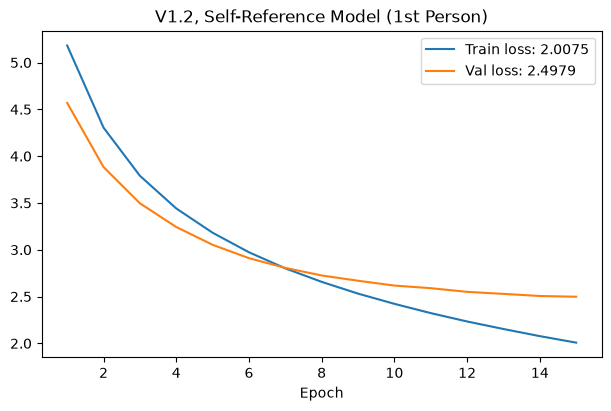

In [20]:
trainer.fit(model, train_data, val_data, 15, '../checkpoints/translator_v1_2-')

## **11.** Saving Tokenizers & Encoders

In [21]:
Data.save_artifacts('../local_data/model_reference/self_ref_1st_person',
                     tokenizer_eng=tokenizer_eng, tokenizer_pol=tokenizer_pol,
                     encoder_eng=encoder_eng, encoder_pol=encoder_pol)

## **12.** Sanity Check

In [22]:
predicter = Predict.PredictionModuleRef(tokenizer_eng, tokenizer_pol, encoder_eng, encoder_pol, model)
predicter.translate_snt("I have never been to Paris.", 'f')

'Nigdy nie byłam w paryżu.'